In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv


# Movie Review Sentiment Analysis Using NLP

## 1. Introduction

This project aims to build a Natural Language Processing (NLP) model
that classifies movie reviews as either positive or negative.

The project will cover:
- Data exploration
- Text preprocessing
- Text representation
- Machine learning baseline
- Deep learning model
- Model evaluation
- Deployment as a simple web application

In [4]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv


In [5]:
import pandas as pd
file_path = "/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv"

df = pd.read_csv(file_path)



In [6]:
df.head()


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [7]:
df.shape

(50000, 2)

In [8]:
df["sentiment"].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [9]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(418)

In [11]:
df = df.drop_duplicates()

In [12]:
df.shape

(49582, 2)

In [13]:
df["sentiment"].value_counts()

sentiment
positive    24884
negative    24698
Name: count, dtype: int64

In [14]:
df["sentiment"].value_counts(normalize=True)

sentiment
positive    0.501876
negative    0.498124
Name: proportion, dtype: float64

In [15]:
df["review_length"] = df["review"].apply(len)

In [16]:
df["review_length"].describe()

count    49582.000000
mean      1310.568230
std        990.762238
min         32.000000
25%        699.000000
50%        971.000000
75%       1592.000000
max      13704.000000
Name: review_length, dtype: float64

In [17]:
df.nsmallest(5, "review_length")[["review", "sentiment", "review_length"]]

,review,sentiment,review_length
27521,"Read the book, forget the movie!",negative,32
31072,"What a script, what a story, what a mess!",negative,41
40817,I hope this group of film-makers never re-unites.,negative,49
28920,Primary plot!Primary direction!Poor interpreta...,negative,51
19874,This movie is terrible but it has some good ef...,negative,52


In [18]:
df.nlargest(5, "review_length")[["review", "sentiment", "review_length"]]

,review,sentiment,review_length
31481,Match 1: Tag Team Table Match Bubba Ray and Sp...,positive,13704
40521,There's a sign on The Lost Highway that says:<...,positive,12988
31240,"(Some spoilers included:)<br /><br />Although,...",positive,12930
31436,"Back in the mid/late 80s, an OAV anime by titl...",positive,12129
5708,**Attention Spoilers**<br /><br />First of all...,positive,10363


In [22]:
df.groupby("sentiment")["review_length"].mean()

sentiment
negative    1294.739615
positive    1326.278532
Name: review_length, dtype: float64

In [23]:
print("POSITIVE REVIEW:")
print(df[df["sentiment"] == "positive"]["review"].iloc[0])

POSITIVE REVIEW:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show 

In [24]:
print("\nNEGATIVE REVIEW:")
print(df[df["sentiment"] == "negative"]["review"].iloc[0])


NEGATIVE REVIEW:
Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.<br /><br />OK, first of all when you're going to make a film you must Decide if its a thriller or a drama! As a drama the movie is watchable. Parents are divorcing & arguing like in real life. And then we have Jake with his closet which totally ruins all the film! I expected to see a BOOGEYMAN similar movie, and instead i watched a drama with some meaningless thriller spots.<br /><br />3 out of 10 just for the well playing parents & descent dialogs. As for the shots with Jake: just ignore them.


In [28]:
import re
from bs4 import BeautifulSoup

def clean_text(text):
    # Remove HTML tags
    text = BeautifulSoup(text, "html.parser").get_text()

    # Convert to lowercase
    text = text.lower()

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [29]:
df["cleaned_review"] = df["review"].apply(clean_text)

In [30]:
df.head()

,review,sentiment,review_length,cleaned_review
0,One of the other reviewers has mentioned that ...,positive,1761,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,positive,998,a wonderful little production. the filming tec...
2,I thought this was a wonderful way to spend ti...,positive,926,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,negative,748,basically there's a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317,"petter mattei's ""love in the time of money"" is..."


In [31]:
print("ORIGINAL:")
print(df["review"].iloc[0][:500])

print("\nCLEANED:")
print(df["cleaned_review"].iloc[0][:500])

ORIGINAL:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ

CLEANED:
one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with me.the first thing that struck me about oz was its brutality and unflinching scenes of violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show pulls no punches with regards to drugs, sex or violence. its is hardcore, in the classic use of the word.it is called oz as

In [32]:
df["cleaned_review"].str.len().describe()

count    49582.000000
mean      1286.282966
std        972.154091
min         32.000000
25%        689.000000
50%        955.000000
75%       1560.000000
max      13584.000000
Name: cleaned_review, dtype: float64

In [33]:
(df["cleaned_review"].str.len() == 0).sum()

np.int64(0)

In [34]:
sample_text = "this movie was absolutely amazing"

tokens = sample_text.split()

print(tokens)

['this', 'movie', 'was', 'absolutely', 'amazing']


In [35]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [38]:
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")

In [39]:
tokenizer.fit_on_texts(df["cleaned_review"])

In [40]:
word_index = tokenizer.word_index

print("Vocabulary size:", len(word_index))


Vocabulary size: 125508


In [41]:
print(list(word_index.items())[:20])

[('<OOV>', 1), ('the', 2), ('and', 3), ('a', 4), ('of', 5), ('to', 6), ('is', 7), ('in', 8), ('it', 9), ('i', 10), ('this', 11), ('that', 12), ('was', 13), ('as', 14), ('for', 15), ('with', 16), ('movie', 17), ('but', 18), ('film', 19), ('on', 20)]


In [42]:
sequences = tokenizer.texts_to_sequences(df["cleaned_review"])

In [43]:
print(sequences[0])

[27, 5, 2, 80, 2121, 45, 1063, 12, 100, 147, 39, 310, 3188, 398, 475, 26, 3202, 33, 23, 203, 14, 11, 7, 624, 48, 595, 16, 68, 2, 87, 148, 12, 3228, 68, 41, 3188, 13, 92, 5367, 3, 1, 135, 5, 571, 60, 267, 8, 203, 36, 2, 658, 139, 1740, 68, 11, 7, 21, 4, 120, 15, 2, 7849, 2336, 38, 1, 11, 120, 2592, 54, 5875, 16, 5504, 6, 1473, 377, 38, 571, 92, 7, 3811, 8, 2, 362, 357, 5, 2, 658, 9, 7, 433, 3188, 14, 12, 7, 2, 1, 355, 6, 2, 1, 6815, 2547, 1072, 1, 9, 2714, 1425, 20, 1, 533, 32, 4639, 2484, 5, 2, 1202, 117, 29, 2, 7018, 25, 2980, 1, 3, 393, 1, 34, 1, 7, 21, 298, 20, 2, 4926, 7494, 533, 7, 345, 6, 106, 1, 8119, 1, 1, 5028, 7850, 2448, 3, 51, 34, 1, 326, 9168, 7428, 1, 3, 8655, 1, 23, 110, 225, 243, 10, 58, 131, 2, 282, 1331, 5, 2, 120, 7, 692, 6, 2, 192, 12, 9, 269, 117, 80, 275, 587, 3031, 835, 180, 1318, 4141, 15, 2512, 1240, 835, 1442, 835, 885, 3188, 149, 954, 183, 2, 87, 398, 10, 123, 209, 3228, 68, 14, 34, 1635, 9, 13, 2259, 10, 413, 131, 10, 13, 1598, 15, 9, 18, 14, 10, 287, 51, 10

In [44]:
sequence_lengths = [len(seq) for seq in sequences]

print("Minimum:", min(sequence_lengths))
print("Maximum:", max(sequence_lengths))
print("Average:", sum(sequence_lengths) / len(sequence_lengths))

Minimum: 6
Maximum: 2466
Average: 231.13783227784276


In [46]:
X = df["cleaned_review"]
y = df["sentiment"]
y = y.map({"negative": 0, "positive": 1})

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [50]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(
    num_words=10000,
    oov_token="<OOV>"
)

In [51]:
tokenizer.fit_on_texts(X_train)

In [52]:
X_train_sequences = tokenizer.texts_to_sequences(X_train)

X_test_sequences = tokenizer.texts_to_sequences(X_test)

In [53]:
X_train_sequences = tokenizer.texts_to_sequences(X_train)

X_test_sequences = tokenizer.texts_to_sequences(X_test)

In [55]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_length = 250

X_train_padded = pad_sequences(
    X_train_sequences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_test_padded = pad_sequences(
    X_test_sequences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

In [56]:
print("Training shape:", X_train_padded.shape)
print("Testing shape:", X_test_padded.shape)

Training shape: (39665, 250)
Testing shape: (9917, 250)


In [57]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, GlobalAveragePooling1D, Dense, Dropout

model = Sequential([
    Input(shape=(max_length,)),
    
    Embedding(
        input_dim=10000,
        output_dim=64
    ),
    
    GlobalAveragePooling1D(),
    
    Dense(64, activation="relu"),
    
    Dropout(0.5),
    
    Dense(1, activation="sigmoid")
])

2026-09-28 12:39:34.245908: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [59]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 250, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 644,225 (2.46 MB)

 Trainable params: 644,225 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

In [60]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [61]:
history = model.fit(
    X_train_padded,
    y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=64
)

Epoch 1/5
496/496 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.7334 - loss: 0.5271 - val_accuracy: 0.8408 - val_loss: 0.3669
Epoch 2/5
496/496 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8633 - loss: 0.3258 - val_accuracy: 0.8771 - val_loss: 0.2980
Epoch 3/5
496/496 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8970 - loss: 0.2641 - val_accuracy: 0.8763 - val_loss: 0.2978
Epoch 4/5
496/496 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9132 - loss: 0.2303 - val_accuracy: 0.8403 - val_loss: 0.3654
Epoch 5/5
496/496 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9211 - loss: 0.2122 - val_accuracy: 0.8738 - val_loss: 0.3203


In [62]:
test_loss, test_accuracy = model.evaluate(
    X_test_padded,
    y_test
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8766 - loss: 0.3101
Test Loss: 0.3100740909576416
Test Accuracy: 0.8765755891799927


In [63]:
import numpy as np

y_pred_prob = model.predict(X_test_padded)

y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [64]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_prob))

Accuracy: 0.8765755772915196
Precision: 0.9099847061393926
Recall: 0.8368495077355836
F1 Score: 0.8718861209964412
ROC-AUC: 0.9510097460463883


In [66]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[4528  412]
 [ 812 4165]]


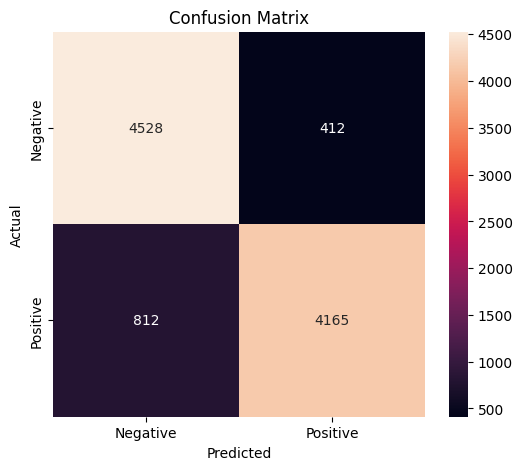

In [67]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [68]:
model.save("sentiment_model.keras")

In [69]:
import os

print(os.path.exists("sentiment_model.keras"))

True


In [70]:
import json

tokenizer_json = tokenizer.to_json()

with open("tokenizer.json", "w") as file:
    file.write(tokenizer_json)

print("Tokenizer saved successfully!")

Tokenizer saved successfully!


In [71]:
import os

print("Model exists:", os.path.exists("sentiment_model.keras"))
print("Tokenizer exists:", os.path.exists("tokenizer.json"))

Model exists: True
Tokenizer exists: True


In [73]:
new_review = "This movie was absolutely amazing. I really enjoyed it!"

In [74]:
cleaned = clean_text(new_review)

print(cleaned)

this movie was absolutely amazing. i really enjoyed it!


In [75]:
sequence = tokenizer.texts_to_sequences([cleaned])

print(sequence)

[[11, 16, 13, 431, 495, 10, 62, 514, 9]]


In [76]:
padded = pad_sequences(
    sequence,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

In [77]:
prediction = model.predict(padded)

print("Probability:", prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Probability: 0.6302786


In [78]:
if prediction[0][0] >= 0.5:
    print("Sentiment: Positive")
else:
    print("Sentiment: Negative")

Sentiment: Positive


In [79]:
new_review = "This movie was terrible. It was boring, disappointing, and a complete waste of time."

In [80]:
cleaned = clean_text(new_review)

sequence = tokenizer.texts_to_sequences([cleaned])

padded = pad_sequences(
    sequence,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

prediction = model.predict(padded)

probability = prediction[0][0]

print("Probability:", probability)

if probability >= 0.5:
    print("Sentiment: Positive")
else:
    print("Sentiment: Negative")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Probability: 0.0031695717
Sentiment: Negative


In [81]:
import os

print(os.listdir("/kaggle/working"))

['.virtual_documents', 'tokenizer.json', 'sentiment_model.keras']


In [84]:
import zipfile

with zipfile.ZipFile("sentiment_app_files.zip", "w") as zipf:
    zipf.write("sentiment_model.keras")
    zipf.write("tokenizer.json")

print("ZIP created successfully!")

ZIP created successfully!


In [85]:
from IPython.display import FileLink

FileLink("sentiment_app_files.zip")

/kaggle/working/sentiment_app_files.zip